In [ ]:
# Import all needed packages

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import re
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Drought Prediction Analysis

This notebook loads sensor and indicator exports, prepares clean monthly datasets, and compares two CDI forecasting approaches.

In [ ]:
# Read data from CSV file as exported Sensor Readings

data_path = Path("data")
if not data_path.exists():
    data_path = Path("../data")

csv_path = data_path / "export_sensor_readings_*.csv"
df = pd.concat(
    map(pd.read_csv, data_path.glob("export_sensor_readings_*.csv"))
)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 162528 entries, 0 to 162527
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   firmware        162528 non-null  str   
 1   original_date   162528 non-null  str   
 2   original_time   162528 non-null  str   
 3   sensor_id       162528 non-null  str   
 4   sensor_meaning  162528 non-null  str   
 5   station_id      162528 non-null  str   
 6   value           162528 non-null  object
 7   id              162528 non-null  int64 
 8   ingested_at     162528 non-null  str   
 9   reading_ts      162528 non-null  str   
dtypes: int64(1), object(1), str(8)
memory usage: 12.4+ MB


/tmp/ipykernel_23916/1837845346.py:6: DtypeWarning: Columns (6: value) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat(


In [ ]:
# Select only important columns from the sensor readings

sensor_df = df[["original_date", "original_time", "station_id", "sensor_id", "sensor_meaning", "value"]]
sensor_df.head()

,original_date,original_time,station_id,sensor_id,sensor_meaning,value
0,'2025/06/17','000000','BAIDOA_MOH','00AT','Air Temperature',21.8
1,'2025/06/16',230000,'BAIDOA_MOH','00AT','Air Temperature',22.6
2,'2025/06/16',220000,'BAIDOA_MOH','00AT','Air Temperature',22.5
3,'2025/06/16',210000,'BAIDOA_MOH','00AT','Air Temperature',22.8
4,'2025/06/16',200000,'BAIDOA_MOH','00AT','Air Temperature',23.9


In [ ]:
# See the unique stations and the number of sensor readings per station

station = sensor_df["station_id"].unique()
sensor_df.groupby(['station_id']).size()

station_id
'000000AWS2'      384
'BAIDOA_MOH'    86208
'MOHADM_AFG'    75936
dtype: int64

## Clean and Prepare Sensor Data

Sensor readings are grouped by station, invalid values such as `---` and `-999` are separated, and export quotes, dates, and numeric values are normalized.

In [ ]:
# For each station create a separate dataset containing only the sensor readings for that station.


def create_station_datasets(dataframe):
    station_datasets = {}
    normalized_station_ids = dataframe["station_id"].astype(str).str.strip("'\"")

    for station_id in normalized_station_ids.dropna().unique():
        station_label = re.sub(r"[^A-Za-z0-9_]+", "_", station_id).strip("_")
        dataset_name = f"df_{station_label}"
        station_datasets[dataset_name] = dataframe[
            normalized_station_ids == station_id
        ].copy()

    return station_datasets


station_datasets = create_station_datasets(sensor_df)
{dataset_name: len(dataset) for dataset_name, dataset in station_datasets.items()}

{'df_BAIDOA_MOH': 86208, 'df_000000AWS2': 384, 'df_MOHADM_AFG': 75936}

In [ ]:
# Remove rows with errors from the source dataframe.
# An error row is defined as a row where the "value" column is "---" or -999.
# The removed rows are appended to the error dataframe.

def remove_error_rows(source_df, error_df=None):
    normalized_values = source_df["value"].map(
        lambda value: value.strip("'\"")
        if isinstance(value, str)
        else value
    )
    numeric_values = pd.to_numeric(normalized_values, errors="coerce")
    error_mask = normalized_values.eq("---") | numeric_values.eq(-999)
    removed_rows = source_df.loc[error_mask].copy()
    cleaned_source_df = source_df.loc[~error_mask].copy()

    if error_df is None:
        error_df = pd.DataFrame(columns=source_df.columns)

    error_df = pd.concat([error_df, removed_rows], ignore_index=True)
    return cleaned_source_df, error_df

In [ ]:
# Clean up data sets from rough or erroneous values
# Errors will be collected in the error_df dataframe.
error_df = None

for dataset_name, dataset in station_datasets.items():
    dataset, error_df = remove_error_rows(dataset, error_df)
    station_datasets[dataset_name] = dataset
    globals()[dataset_name] = dataset

{dataset_name: len(dataset) for dataset_name, dataset in station_datasets.items()} | {"error_df": len(error_df)}

{'df_BAIDOA_MOH': 85952,
 'df_000000AWS2': 2,
 'df_MOHADM_AFG': 75177,
 'error_df': 1397}

In [ ]:
# Remove quotes around fields, format date fields and number fields correctly

def remove_quotes(dataframe):
    cleaned_dataframe = dataframe.copy()

    for column in cleaned_dataframe.columns:
        cleaned_dataframe[column] = cleaned_dataframe[column].map(
            lambda value: value.strip("'\"")
            if isinstance(value, str)
            else value
        )

    return cleaned_dataframe


def clean_dataframe(dataframe):
    cleaned_dataframe = dataframe.copy()

    if "original_date" in cleaned_dataframe.columns:
        cleaned_dataframe["original_date"] = pd.to_datetime(
            cleaned_dataframe["original_date"],
            format="%Y/%m/%d",
            errors="coerce",
        )

    if "value" in cleaned_dataframe.columns:
        cleaned_dataframe["value"] = pd.to_numeric(
            cleaned_dataframe["value"],
            errors="coerce",
        )

    return cleaned_dataframe


for dataset_name, dataset in station_datasets.items():
    dataset_without_quotes = remove_quotes(dataset)
    cleaned_dataset = clean_dataframe(dataset_without_quotes)
    station_datasets[dataset_name] = cleaned_dataset
    globals()[dataset_name] = cleaned_dataset
    print(dataset_name)
    display(cleaned_dataset.head())

df_BAIDOA_MOH


,original_date,original_time,station_id,sensor_id,sensor_meaning,value
0,2025-06-17,000000,BAIDOA_MOH,00AT,Air Temperature,21.8
1,2025-06-16,230000,BAIDOA_MOH,00AT,Air Temperature,22.6
2,2025-06-16,220000,BAIDOA_MOH,00AT,Air Temperature,22.5
3,2025-06-16,210000,BAIDOA_MOH,00AT,Air Temperature,22.8
4,2025-06-16,200000,BAIDOA_MOH,00AT,Air Temperature,23.9


df_000000AWS2


,original_date,original_time,station_id,sensor_id,sensor_meaning,value
9588,2025-08-13,100000,000000AWS2,SOLR,Solar Radiation,0.0
9780,2025-08-13,100000,000000AWS2,SOLR,Solar Radiation,0.0


df_MOHADM_AFG


,original_date,original_time,station_id,sensor_id,sensor_meaning,value
10836,2025-08-20,110000,MOHADM_AFG,SOLR,Solar Radiation,0.00
10932,2025-08-20,110000,MOHADM_AFG,SOLR,Solar Radiation,0.00
11028,2025-08-20,110000,MOHADM_AFG,SOLR,Solar Radiation,0.00
11124,2025-08-20,110000,MOHADM_AFG,SOLR,Solar Radiation,0.00
11952,2025-08-20,120000,MOHADM_AFG,RAIN,Rainfall,0.01


In [ ]:
# Show what sensor ID means

def show_sensor_pairs(dataframe):
    display(
        dataframe[["sensor_id", "sensor_meaning"]]
        .drop_duplicates()
        .sort_values(["sensor_id", "sensor_meaning"])
        .reset_index(drop=True)
    )


show_sensor_pairs(df)

,sensor_id,sensor_meaning
0,'00AP','Atmospheric Pressure'
1,'00AT','Air Temperature'
2,'00DP','Dew Point'
3,'00RH','Relative Humidity'
4,'00WD','Wind Direction'
5,'00WS','Wind Speed'
6,'RAIN','Rainfall'
7,'SOLR','Solar Radiation'


In [ ]:
# Reframe data sets so each sensor value represents separate variable for further analysis

def pivot_sensor_values(dataframe):
    return (
        dataframe.pivot_table(
            index=["original_date", "original_time"],
            columns="sensor_id",
            values="value",
            aggfunc="first",
        )
        .reset_index()
        .rename_axis(columns=None)
    )


df_BAIDOA_MOH_pivot = pivot_sensor_values(df_BAIDOA_MOH)
df_BAIDOA_MOH_pivot.head()

,original_date,original_time,00AP,00AT,00DP,00RH,00WD,00WS,RAIN,SOLR
0,2025-06-16,140000,NaN,NaN,NaN,NaN,127.0,1.0,0.0,28.8
1,2025-06-16,150000,962.0,29.5,18.4,51.4,271.9,1.2,0.0,1316.8
2,2025-06-16,160000,961.9,29.1,18.5,52.8,261.1,0.5,0.0,3157.3
3,2025-06-16,170000,961.3,29.1,18.5,53.1,174.7,3.1,0.0,3040.5
4,2025-06-16,180000,961.8,27.5,19.5,62.1,122.8,3.7,0.0,3680.5


## Transform and Aggregate Weather Readings

Sensor IDs are pivoted into separate variables. Wind direction and speed are combined into weighted wind (`WNDW`), then daily weather metrics are aggregated using rules based on their physical meaning.

In [ ]:
# Note: Wind direction and wind speed are combined into a single variable "WNDW" representing weighted wind.
# It will be used later to aggregate wind data for analysis.

df_BAIDOA_MOH_wndw = df_BAIDOA_MOH_pivot.copy()
df_BAIDOA_MOH_wndw["WNDW"] = (
    df_BAIDOA_MOH_wndw["00WD"] * df_BAIDOA_MOH_wndw["00WS"]
)
df_BAIDOA_MOH_wndw = df_BAIDOA_MOH_wndw.drop(columns=["00WD", "00WS"])
df_BAIDOA_MOH_wndw.head()

,original_date,original_time,00AP,00AT,00DP,00RH,RAIN,SOLR,WNDW
0,2025-06-16,140000,NaN,NaN,NaN,NaN,0.0,28.8,127.00
1,2025-06-16,150000,962.0,29.5,18.4,51.4,0.0,1316.8,326.28
2,2025-06-16,160000,961.9,29.1,18.5,52.8,0.0,3157.3,130.55
3,2025-06-16,170000,961.3,29.1,18.5,53.1,0.0,3040.5,541.57
4,2025-06-16,180000,961.8,27.5,19.5,62.1,0.0,3680.5,454.36


In [ ]:
# Aggregation. Note, each metric has its own aggregation rule depending on sensor meaning.
# This function aggregates Wind metrics separately

def aggregate_sensor_values_by_day(dataframe):
    daily_dataframe = dataframe.copy()
    daily_dataframe["original_date"] = pd.to_datetime(
        daily_dataframe["original_date"],
        errors="coerce",
    ).dt.normalize()

    sensor_columns = [
        "00AP",
        "00AT",
        "00DP",
        "00RH",
        "00WD",
        "00WS",
        "RAIN",
        "SOLR",
    ]
    sensor_columns = [
        column for column in sensor_columns if column in daily_dataframe.columns
    ]

    daily_dataframe[sensor_columns] = daily_dataframe[sensor_columns].apply(
        pd.to_numeric,
        errors="coerce",
    )

    aggregation_rules = {
        "00AP": "mean",
        "00AT": "mean",
        "00DP": "mean",
        "00RH": "mean",
        "00WD": "circular_mean",
        "00WS": "mean",
        "RAIN": "sum",
        "SOLR": "sum",
    }

    def circular_mean(values):
        radians = pd.Series(values).dropna().to_numpy() * np.pi / 180
        if len(radians) == 0:
            return np.nan
        angle = np.degrees(
            np.arctan2(np.sin(radians).mean(), np.cos(radians).mean())
        ) % 360
        return 0.0 if np.isclose(angle, 360.0) else angle

    aggregated = {}
    for column in sensor_columns:
        rule = aggregation_rules.get(column, "mean")
        aggregation_function = (
            circular_mean if rule == "circular_mean" else rule
        )
        aggregated[column] = daily_dataframe.groupby("original_date")[column].agg(
            aggregation_function
        )

    return pd.DataFrame(aggregated).reset_index()


df_BAIDOA_MOH_daily = aggregate_sensor_values_by_day(df_BAIDOA_MOH_pivot)
df_BAIDOA_MOH_daily.head()

,original_date,00AP,00AT,00DP,00RH,00WD,00WS,RAIN,SOLR
0,2025-06-16,963.000000,25.744444,19.466667,70.022222,170.384257,1.800000,0.00,11383.0
1,2025-06-17,963.941667,23.266667,19.966667,82.570833,162.021242,1.679167,0.15,249541.2
2,2025-06-18,963.541667,24.841667,19.983333,75.904167,175.247180,1.895833,0.08,257073.2
3,2025-06-19,963.625000,25.383333,19.220833,70.416667,168.097075,1.766667,0.01,276580.0
4,2025-06-20,963.500000,25.495833,18.687500,68.454167,166.101610,2.112500,0.06,278404.6


In [ ]:
# Aggregation. Note, each metric has its own aggregation rule depending on sensor meaning.
# This function aggregates Wind metrics combined as weighted values


def aggregate_sensor_values_by_day_with_weighted_wind(dataframe):
    daily_dataframe = dataframe.copy()
    daily_dataframe["original_date"] = pd.to_datetime(
        daily_dataframe["original_date"],
        errors="coerce",
    ).dt.normalize()

    sensor_columns = [
        "00AP",
        "00AT",
        "00DP",
        "00RH",
        "WNDW",
        "RAIN",
        "SOLR",
    ]
    sensor_columns = [
        column for column in sensor_columns if column in daily_dataframe.columns
    ]

    daily_dataframe[sensor_columns] = daily_dataframe[sensor_columns].apply(
        pd.to_numeric,
        errors="coerce",
    )

    aggregation_rules = {
        "00AP": "mean",
        "00AT": "mean",
        "00DP": "mean",
        "00RH": "mean",
        "WNDW": "circular_mean",
        "RAIN": "sum",
        "SOLR": "sum",
    }

    def circular_mean(values):
        radians = pd.Series(values).dropna().to_numpy() * np.pi / 180
        if len(radians) == 0:
            return np.nan
        angle = np.degrees(
            np.arctan2(np.sin(radians).mean(), np.cos(radians).mean())
        ) % 360
        return 0.0 if np.isclose(angle, 360.0) else angle

    aggregated = {}
    for column in sensor_columns:
        rule = aggregation_rules.get(column, "mean")
        aggregation_function = circular_mean if rule == "circular_mean" else rule
        aggregated[column] = daily_dataframe.groupby("original_date")[column].agg(
            aggregation_function
        )

    return pd.DataFrame(aggregated).reset_index()


df_BAIDOA_MOH_wndw_daily = aggregate_sensor_values_by_day_with_weighted_wind(
    df_BAIDOA_MOH_wndw
)
df_BAIDOA_MOH_wndw_daily.head()

,original_date,00AP,00AT,00DP,00RH,WNDW,RAIN,SOLR
0,2025-06-16,963.000000,25.744444,19.466667,70.022222,162.954705,0.00,11383.0
1,2025-06-17,963.941667,23.266667,19.966667,82.570833,120.041469,0.15,249541.2
2,2025-06-18,963.541667,24.841667,19.983333,75.904167,144.363544,0.08,257073.2
3,2025-06-19,963.625000,25.383333,19.220833,70.416667,220.550561,0.01,276580.0
4,2025-06-20,963.500000,25.495833,18.687500,68.454167,90.822267,0.06,278404.6


In [ ]:
# Column Correlation Calculation
#
# This function calculates the correlation between numeric columns in a given data frame.

def calculate_column_correlations(dataframe):
    numeric_data = dataframe.select_dtypes(include="number")
    return numeric_data.corr()


calculate_column_correlations(df_BAIDOA_MOH_daily)

,00AP,00AT,00DP,00RH,00WD,00WS,RAIN,SOLR
00AP,1.000000,-0.730573,0.085867,0.360518,0.591459,0.191730,-0.070086,-0.488112
00AT,-0.730573,1.000000,-0.320096,-0.682043,-0.780708,-0.030193,-0.191601,0.747784
00DP,0.085867,-0.320096,1.000000,0.894454,0.516435,-0.148478,0.288427,-0.387177
00RH,0.360518,-0.682043,0.894454,1.000000,0.711985,-0.168468,0.362818,-0.620144
00WD,0.591459,-0.780708,0.516435,0.711985,1.000000,0.042345,0.203705,-0.570956
00WS,0.191730,-0.030193,-0.148478,-0.168468,0.042345,1.000000,-0.250940,-0.017682
RAIN,-0.070086,-0.191601,0.288427,0.362818,0.203705,-0.250940,1.000000,-0.212737
SOLR,-0.488112,0.747784,-0.387177,-0.620144,-0.570956,-0.017682,-0.212737,1.000000


In [20]:
calculate_column_correlations(df_BAIDOA_MOH_wndw_daily)

,00AP,00AT,00DP,00RH,WNDW,RAIN,SOLR
00AP,1.000000,-0.730573,0.085867,0.360518,0.288691,-0.070086,-0.488112
00AT,-0.730573,1.000000,-0.320096,-0.682043,-0.364561,-0.191601,0.747784
00DP,0.085867,-0.320096,1.000000,0.894454,0.245175,0.288427,-0.387177
00RH,0.360518,-0.682043,0.894454,1.000000,0.303390,0.362818,-0.620144
WNDW,0.288691,-0.364561,0.245175,0.303390,1.000000,-0.042809,-0.239689
RAIN,-0.070086,-0.191601,0.288427,0.362818,-0.042809,1.000000,-0.212737
SOLR,-0.488112,0.747784,-0.387177,-0.620144,-0.239689,-0.212737,1.000000


## Explore CDI Alerts and Thresholds

CDI alert exports are filtered for Baydhaba and plotted against threshold periods to show when conditions move between normal, alert, and alarm states.

In [24]:
# Read CDI Data
data_path = Path("data")
if not data_path.exists():
    data_path = Path("../data")

csv_path = data_path / "export_all_cdi_alert_*.csv"
df_cdi = pd.concat(map(pd.read_csv, data_path.glob("export_all_cdi_alert_*.csv")))
df_cdi.info()

<class 'pandas.DataFrame'>
RangeIndex: 1504 entries, 0 to 1503
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   value      1504 non-null   float64
 1   district   1504 non-null   str    
 2   month      1504 non-null   str    
 3   region     1504 non-null   str    
 4   threshold  1504 non-null   str    
 5   year       1504 non-null   int64  
dtypes: float64(1), int64(1), str(4)
memory usage: 70.6 KB


In [ ]:
# Filtering CDI Data for Baydhaba District

df_cdi_bai = df_cdi.loc[df_cdi["district"] == "'Baydhaba'"]
df_cdi_bai.head()

,value,district,month,region,threshold,year
470,0.752,'Baydhaba','03','Bay','Alarm',2026
471,0.967,'Baydhaba','05','Bay','Alert',2026
472,0.585,'Baydhaba','01','Bay','Alarm',2026
473,0.561,'Baydhaba','02','Bay','Alarm',2026
474,1.012,'Baydhaba','04','Bay','Normal',2026


In [26]:
df_cdi_bai = remove_quotes(df_cdi_bai)
df_cdi_bai.head()

,value,district,month,region,threshold,year
470,0.752,Baydhaba,03,Bay,Alarm,2026
471,0.967,Baydhaba,05,Bay,Alert,2026
472,0.585,Baydhaba,01,Bay,Alarm,2026
473,0.561,Baydhaba,02,Bay,Alarm,2026
474,1.012,Baydhaba,04,Bay,Normal,2026


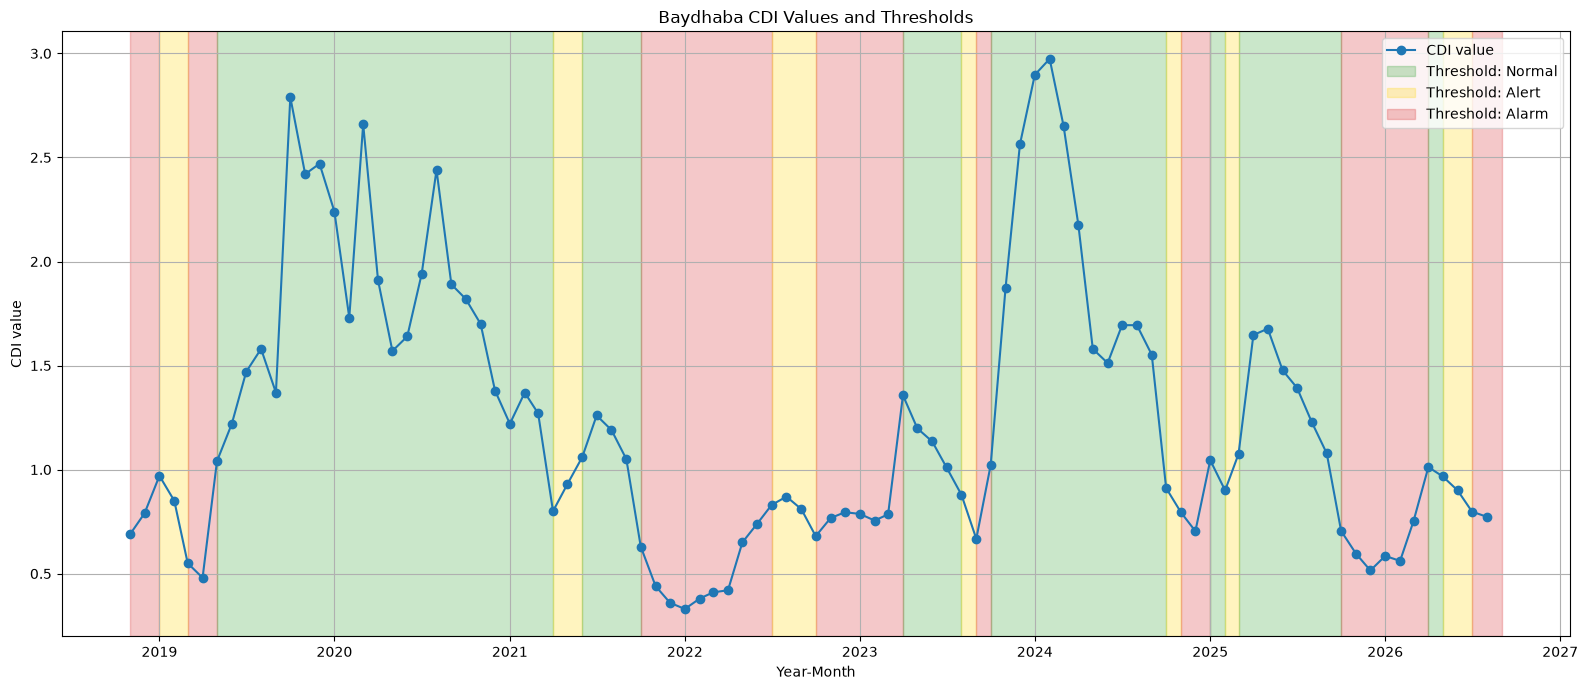

In [ ]:
# Show chart for CDI metrics with thresholds shown as colored areas

cdi_chart_data = df_cdi_bai.copy()
cdi_chart_data["year-month"] = pd.to_datetime(
    {
        "year": pd.to_numeric(cdi_chart_data["year"], errors="coerce"),
        "month": pd.to_numeric(cdi_chart_data["month"], errors="coerce"),
        "day": 1,
    },
    errors="coerce",
)
cdi_chart_data["value"] = pd.to_numeric(cdi_chart_data["value"], errors="coerce")
cdi_chart_data = cdi_chart_data.dropna(
    subset=["year-month", "value", "threshold"]
).sort_values("year-month")

threshold_colors = {
    "Normal": "tab:green",
    "Alert": "gold",
    "Alarm": "tab:red",
}
threshold_periods = cdi_chart_data["threshold"].ne(
    cdi_chart_data["threshold"].shift()
).cumsum()

fig, ax = plt.subplots(figsize=(16, 7))
for _, period_data in cdi_chart_data.groupby(threshold_periods):
    threshold = str(period_data["threshold"].iloc[0])
    start_date = period_data["year-month"].iloc[0]
    end_date = period_data["year-month"].iloc[-1] + pd.offsets.MonthBegin(1)
    ax.axvspan(
        start_date,
        end_date,
        color=threshold_colors[threshold],
        alpha=0.25,
    )

ax.plot(
    cdi_chart_data["year-month"],
    cdi_chart_data["value"],
    color="tab:blue",
    marker="o",
    label="CDI value",
)
ax.set_title("Baydhaba CDI Values and Thresholds")
ax.set_xlabel("Year-Month")
ax.set_ylabel("CDI value")
ax.grid(True)

threshold_legend = [
    Patch(color=color, alpha=0.25, label=f"Threshold: {threshold}")
    for threshold, color in threshold_colors.items()
]
value_line, value_label = ax.get_legend_handles_labels()
ax.legend(value_line + threshold_legend, value_label + [item.get_label() for item in threshold_legend])

plt.tight_layout()
plt.show()

## Prepare Baydhaba Indicator Data

Indicator exports are filtered for Baydhaba, unnecessary fields are removed, and CDI, NDVI, and rainfall are aligned by month for analysis.

In [28]:
# Read indicator data
csv_path = data_path / "export_indicator_data*.csv"
df_ind = pd.concat(map(pd.read_csv, data_path.glob("export_indicator_data*.csv")))
df_ind.info()  
df_ind = remove_quotes(df_ind)
df_ind.head()

<class 'pandas.DataFrame'>
RangeIndex: 20784 entries, 0 to 20783
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   month       20784 non-null  str    
 1   id          20784 non-null  int64  
 2   value       20534 non-null  float64
 3   commodity   12832 non-null  str    
 4   district    20784 non-null  str    
 5   indicator   20784 non-null  str    
 6   region      20784 non-null  str    
 7   created_at  20784 non-null  str    
dtypes: float64(1), int64(1), str(6)
memory usage: 1.3 MB


,month,id,value,commodity,district,indicator,region,created_at
0,2018-11-01,2,0.38,NaN,Marka,cdi,Lower Shabelle,2024-01-11T13:05:40.159401+00:00
1,2018-11-01,3,0.48,NaN,Afgooye,cdi,Lower Shabelle,2024-01-11T13:05:40.159401+00:00
2,2018-11-01,4,0.28,NaN,Baraawe,cdi,Lower Shabelle,2024-01-11T13:05:40.159401+00:00
3,2018-11-01,5,0.35,NaN,Kurtunwaarey,cdi,Lower Shabelle,2024-01-11T13:05:40.159401+00:00
4,2018-11-01,6,0.38,NaN,Qoryooley,cdi,Lower Shabelle,2024-01-11T13:05:40.159401+00:00


In [ ]:
#Select data only for Baydhaba district and drop unnecessary columns

df_ind_bai = df_ind.loc[df_ind['district'] == 'Baydhaba'].drop(columns=['id', 'commodity', 'created_at'])
df_ind_bai.head()

,month,value,district,indicator,region
7,2018-11-01,0.69,Baydhaba,cdi,Bay
23,2018-12-01,0.79,Baydhaba,cdi,Bay
39,2019-01-01,0.97,Baydhaba,cdi,Bay
55,2019-02-01,0.85,Baydhaba,cdi,Bay
71,2019-03-01,0.55,Baydhaba,cdi,Bay


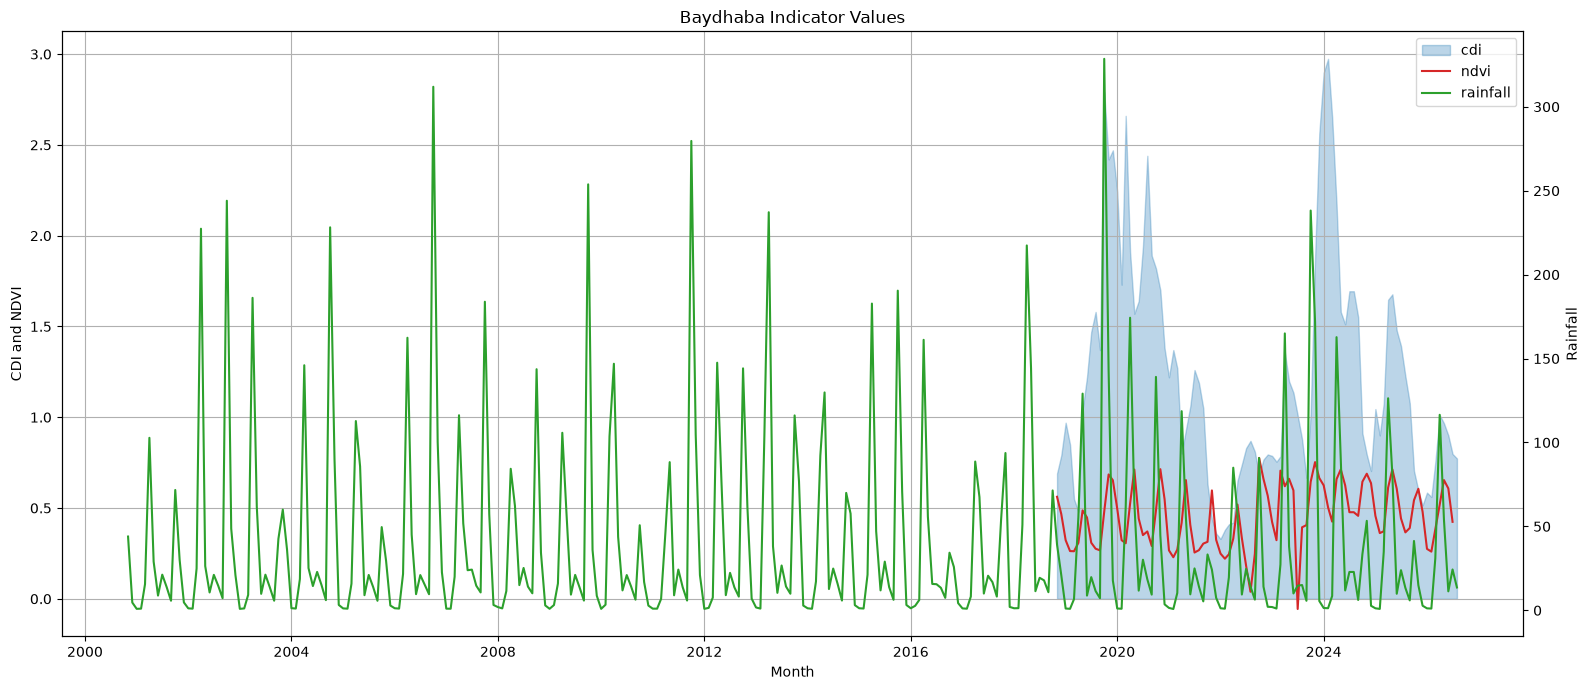

In [ ]:
#Show on the chart the indicator values for Baydhaba district, CDI index is shown as area

chart_data = df_ind_bai.drop(columns=["district", "region"]).copy()
chart_data = chart_data.loc[chart_data["indicator"] != "market"]
chart_data["month"] = pd.to_datetime(chart_data["month"], errors="coerce")
chart_data["value"] = pd.to_numeric(chart_data["value"], errors="coerce")
chart_data = chart_data.dropna(subset=["month", "value"])
chart_data = chart_data.loc[
    ~((chart_data["indicator"] == "ndvi") & (chart_data["value"] == 13.637))
]

fig, ax_left = plt.subplots(figsize=(16, 7))
ax_right = ax_left.twinx()

cdi_data = chart_data.loc[chart_data["indicator"] == "cdi"].sort_values("month")
ax_left.fill_between(
    cdi_data["month"],
    cdi_data["value"],
    color="tab:blue",
    alpha=0.3,
    label="cdi",
)

ndvi_data = chart_data.loc[chart_data["indicator"] == "ndvi"].sort_values("month")
ax_left.plot(
    ndvi_data["month"],
    ndvi_data["value"],
    color="tab:red",
    label="ndvi",
)

rainfall_data = chart_data.loc[chart_data["indicator"] == "rainfall"].sort_values("month")
ax_right.plot(
    rainfall_data["month"],
    rainfall_data["value"],
    color="tab:green",
    label="rainfall",
)

ax_left.set_title("Baydhaba Indicator Values")
ax_left.set_xlabel("Month")
ax_left.set_ylabel("CDI and NDVI")
ax_right.set_ylabel("Rainfall")
ax_left.grid(True)

left_lines, left_labels = ax_left.get_legend_handles_labels()
right_lines, right_labels = ax_right.get_legend_handles_labels()
ax_left.legend(left_lines + right_lines, left_labels + right_labels)

plt.tight_layout()
plt.show()

## Forecast CDI from BAIDOA_MOH Weather Data

A Random Forest uses only `00AT`, `00RH`, `WNDW`, and `RAIN`. Monthly weather values are matched to the following month's CDI, evaluated with a chronological holdout, and refit for the next-month forecast.

In [ ]:
# Random Forest model for CDI forecast based on sensor data, only four uncorrelated variables are taken into account

feature_columns = ["00AT", "00RH", "WNDW", "RAIN"]
weather_data = df_BAIDOA_MOH_wndw.copy()
missing_features = [
    column for column in feature_columns if column not in weather_data.columns
]
if missing_features:
    raise ValueError(f"Missing weather features: {missing_features}")

weather_data["month"] = pd.to_datetime(
    weather_data["original_date"], errors="coerce"
).dt.to_period("M").dt.to_timestamp()
weather_data[feature_columns] = weather_data[feature_columns].apply(
    pd.to_numeric, errors="coerce"
)
monthly_weather = (
    weather_data.groupby("month", as_index=False)
    .agg(
        {
            "00AT": "mean",
            "00RH": "mean",
            "WNDW": "mean",
            "RAIN": "sum",
        }
    )
    .dropna(subset=feature_columns)
)

cdi_monthly = (
    df_ind_bai.loc[df_ind_bai["indicator"] == "cdi"]
    .assign(
        month=lambda dataframe: pd.to_datetime(
            dataframe["month"], errors="coerce"
        ).dt.to_period("M").dt.to_timestamp(),
        cdi=lambda dataframe: pd.to_numeric(dataframe["value"], errors="coerce"),
    )
    .dropna(subset=["month", "cdi"])
    .groupby("month", as_index=False)["cdi"]
    .mean()
)

model_data = (
    monthly_weather.assign(
        target_month=lambda dataframe: dataframe["month"] + pd.offsets.MonthBegin(1)
    )
    .merge(
        cdi_monthly.rename(columns={"month": "target_month", "cdi": "target_cdi"}),
        on="target_month",
        how="inner",
    )
    .sort_values("target_month")
)
if len(model_data) < 8:
    raise ValueError("At least 8 monthly weather/CDI pairs are required.")

X = model_data[feature_columns]
y = model_data["target_cdi"]
test_size = min(6, max(1, len(model_data) // 5))
X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
test_predictions = model.predict(X_test)
test_mae = mean_absolute_error(y_test, test_predictions)

final_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
final_model.fit(X, y)
latest_weather = monthly_weather.sort_values("month").iloc[-1]
next_month = latest_weather["month"] + pd.offsets.MonthBegin(1)
next_month_prediction = final_model.predict(
    latest_weather[feature_columns].to_frame().T
)[0]

ml_cdi_forecast = pd.DataFrame(
    {
        "month": [next_month],
        "predicted_cdi": [next_month_prediction],
        "model": ["RandomForestRegressor"],
        "features": [", ".join(feature_columns)],
        "test_mae": [test_mae],
    }
)

print(f"RandomForestRegressor holdout MAE: {test_mae:.3f}")
display(ml_cdi_forecast)

RandomForestRegressor holdout MAE: 0.233


,month,predicted_cdi,model,features,test_mae
0,2026-10-01,0.789254,RandomForestRegressor,"00AT, 00RH, WNDW, RAIN",0.232848


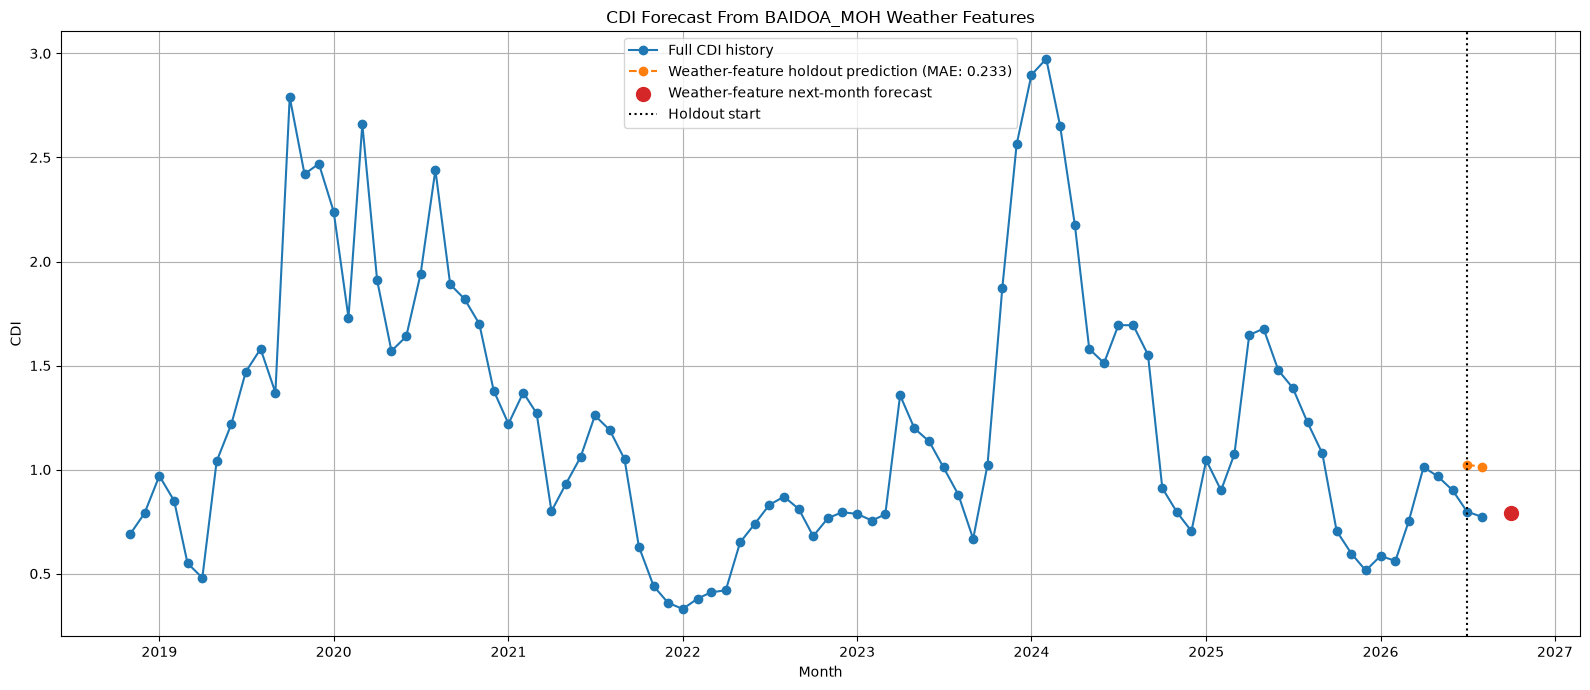

In [38]:
# Chart for Random Forest weather-feature forecast
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(
    cdi_monthly["month"],
    cdi_monthly["cdi"],
    color="tab:blue",
    marker="o",
    label="Full CDI history",
)
ax.plot(
    model_data["target_month"].iloc[-test_size:],
    test_predictions,
    color="tab:orange",
    linestyle="--",
    marker="o",
    label=f"Weather-feature holdout prediction (MAE: {test_mae:.3f})",
)
ax.scatter(
    ml_cdi_forecast["month"],
    ml_cdi_forecast["predicted_cdi"],
    color="tab:red",
    s=100,
    zorder=3,
    label="Weather-feature next-month forecast",
)
ax.axvline(
    model_data["target_month"].iloc[-test_size],
    color="black",
    linestyle=":",
    label="Holdout start",
)
ax.set_title("CDI Forecast From BAIDOA_MOH Weather Features")
ax.set_xlabel("Month")
ax.set_ylabel("CDI")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

## Forecast CDI from Rainfall and Current CDI

A Gradient Boosting model uses rainfall, log-transformed rainfall, and the current CDI value. This adds recent drought-state context while keeping rainfall as the main external predictor.

Improved model holdout MAE: 0.087


,month,rainfall_used,current_cdi_used,predicted_cdi,model,features,test_mae
0,2026-09-01,13.637,0.773,0.828654,GradientBoostingRegressor,"rainfall, log_rainfall, cdi",0.087017


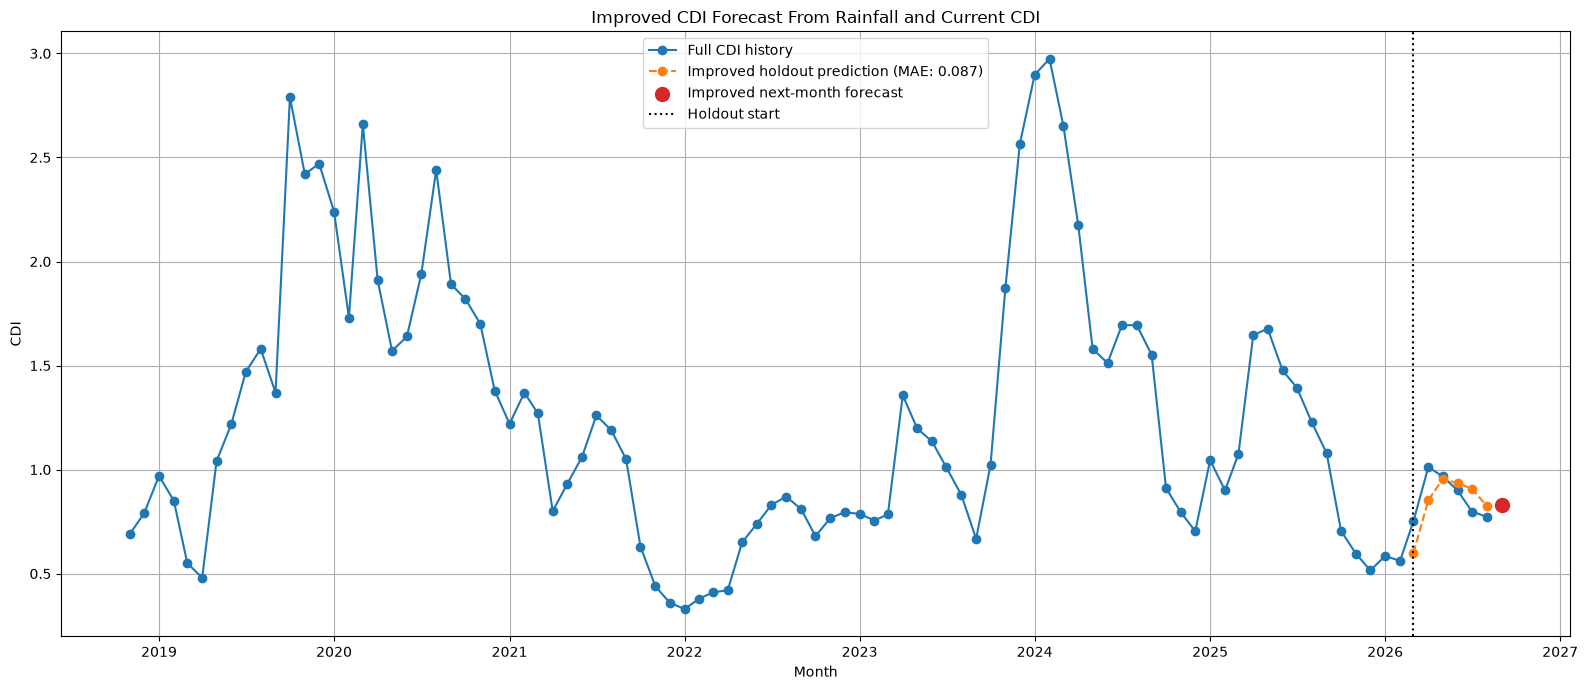

In [ ]:
# CDI forecast using rainfall and current CDI context from Indicator data

from sklearn.ensemble import GradientBoostingRegressor

rainfall_indicator_data = (
    df_ind_bai.loc[df_ind_bai["indicator"].isin(["cdi", "rainfall"])]
    .assign(
        month=lambda dataframe: pd.to_datetime(
            dataframe["month"], errors="coerce"
        ).dt.to_period("M").dt.to_timestamp(),
        value=lambda dataframe: pd.to_numeric(dataframe["value"], errors="coerce"),
    )
    .dropna(subset=["month", "value"])
    .pivot_table(
        index="month",
        columns="indicator",
        values="value",
        aggfunc="mean",
    )
    .reset_index()
    .sort_values("month")
)

improved_model_data = (
    rainfall_indicator_data[["month", "cdi", "rainfall"]]
    .dropna()
    .assign(
        log_rainfall=lambda dataframe: np.log1p(
            dataframe["rainfall"].clip(lower=0)
        ),
        target_month=lambda dataframe: dataframe["month"] + pd.offsets.MonthBegin(1),
    )
    .merge(
        cdi_monthly.rename(columns={"month": "target_month", "cdi": "target_cdi"}),
        on="target_month",
        how="inner",
    )
    .sort_values("target_month")
)
if len(improved_model_data) < 8:
    raise ValueError("At least 8 monthly rainfall/CDI pairs are required.")

improved_features = ["rainfall", "log_rainfall", "cdi"]
X_improved = improved_model_data[improved_features]
y_improved = improved_model_data["target_cdi"]
improved_test_size = min(6, max(1, len(improved_model_data) // 5))
X_improved_train = X_improved.iloc[:-improved_test_size]
X_improved_test = X_improved.iloc[-improved_test_size:]
y_improved_train = y_improved.iloc[:-improved_test_size]
y_improved_test = y_improved.iloc[-improved_test_size:]

improved_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.03,
    max_depth=2,
    loss="huber",
    random_state=42,
)
improved_model.fit(X_improved_train, y_improved_train)
improved_test_predictions = improved_model.predict(X_improved_test)
improved_test_mae = mean_absolute_error(
    y_improved_test, improved_test_predictions
)

final_improved_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.03,
    max_depth=2,
    loss="huber",
    random_state=42,
)
final_improved_model.fit(X_improved, y_improved)
latest_predictors = rainfall_indicator_data.dropna(
    subset=["cdi", "rainfall"]
).iloc[-1].copy()
latest_predictors["log_rainfall"] = np.log1p(
    max(latest_predictors["rainfall"], 0)
)
improved_next_month = latest_predictors["month"] + pd.offsets.MonthBegin(1)
improved_next_month_prediction = final_improved_model.predict(
    latest_predictors[improved_features].to_frame().T
)[0]

improved_cdi_forecast = pd.DataFrame(
    {
        "month": [improved_next_month],
        "rainfall_used": [latest_predictors["rainfall"]],
        "current_cdi_used": [latest_predictors["cdi"]],
        "predicted_cdi": [improved_next_month_prediction],
        "model": ["GradientBoostingRegressor"],
        "features": [", ".join(improved_features)],
        "test_mae": [improved_test_mae],
    }
)

print(f"Improved model holdout MAE: {improved_test_mae:.3f}")
display(improved_cdi_forecast)

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(
    cdi_monthly["month"],
    cdi_monthly["cdi"],
    color="tab:blue",
    marker="o",
    label="Full CDI history",
)
ax.plot(
    improved_model_data["target_month"].iloc[-improved_test_size:],
    improved_test_predictions,
    color="tab:orange",
    linestyle="--",
    marker="o",
    label=f"Improved holdout prediction (MAE: {improved_test_mae:.3f})",
)
ax.scatter(
    improved_cdi_forecast["month"],
    improved_cdi_forecast["predicted_cdi"],
    color="tab:red",
    s=100,
    zorder=3,
    label="Improved next-month forecast",
)
ax.axvline(
    improved_model_data["target_month"].iloc[-improved_test_size],
    color="black",
    linestyle=":",
    label="Holdout start",
)
ax.set_title("Improved CDI Forecast From Rainfall and Current CDI")
ax.set_xlabel("Month")
ax.set_ylabel("CDI")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

## Compare Forecasts

The final comparison keeps both predictions visible: the BAIDOA_MOH weather forecast and the rainfall-plus-current-CDI forecast, including each model's chronological holdout MAE.

In [ ]:
#Compare predictins based on different input data sets

forecast_comparison = pd.concat(
    [
        ml_cdi_forecast.assign(
            forecast_source="BAIDOA_MOH weather: 00AT, 00RH, WNDW, RAIN"
        ).rename(columns={"test_mae": "holdout_mae"}),
        improved_cdi_forecast.assign(
            forecast_source="Indicator rainfall + current CDI"
        ).rename(columns={"test_mae": "holdout_mae"}),
    ],
    ignore_index=True,
)

display(
    forecast_comparison[
        [
            "forecast_source",
            "month",
            "predicted_cdi",
            "model",
            "holdout_mae",
        ]
    ]
)

,forecast_source,month,predicted_cdi,model,holdout_mae
0,"BAIDOA_MOH weather: 00AT, 00RH, WNDW, RAIN",2026-10-01,0.789254,RandomForestRegressor,0.232848
1,Indicator rainfall + current CDI,2026-09-01,0.828654,GradientBoostingRegressor,0.087017
